In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

result_file = 'result_gap_size.log'
result_file_success = 'result_success_gap_size.csv'

In [2]:
df_loaded = pd.read_csv("data_9992_final/performance_disruptive_obs.20_gap.size.log")
data = (
    df_loaded.assign(
        average_reward=df_loaded["total_reward"] / df_loaded["steps"].replace(0, pd.NA)
    )
    .fillna(0)
    .groupby("name")
    .agg({
        "steps": list,
        "average_reward": list,
        "success": list,
        "smoothness": list,
        "heading_deviation": list,
        "others": list
    })
    .to_dict("index")
)

with open(result_file, 'w') as f:
    f.write("Model,Gap,AvgReward,Steps,Success,Smooth,Deviation\n")
    for key, value in data.items():
        #convert
        steps = np.mean(value['steps'])
        mean_reward = np.mean(value['average_reward'])
        #count success over length of np array
        success = np.sum(value['success'])/ len(value['success'])
        smoothness = np.mean(value['smoothness'])
        heading_deviation = np.mean(value['heading_deviation'])


        #dreamer_obs.30_norm.60.90_gap.0.5
        #dreamer_obs.30_norm.60.90_gap.0.5_recovery

        gap_range = key.split('_')[3]
        gap = int(gap_range.split('.')[2])
        
        key = 'Dreamer(Recovery)' if 'recovery' in key else 'Dreamer' 
        obs = 30
        horizon = 30

        f.write(f"{key},{gap},{mean_reward},{steps},{success},{smoothness},{heading_deviation}\n")

In [3]:
#read csv file into a pandas DataFrame
raw_data = pd.read_csv(result_file)
#sort by gap
raw_data = raw_data.sort_values(by=['Gap'])
print(raw_data.shape)
print(raw_data)

(10, 7)
               Model  Gap  AvgReward   Steps  Success      Smooth  Deviation
0            Dreamer    5  -0.028946  553.65     0.56  629.960676   5.036619
1  Dreamer(Recovery)    5  -0.022529  617.42     0.66  661.646314   5.194209
8            Dreamer   10  -0.019488  639.72     0.68  624.458906   5.283457
9  Dreamer(Recovery)   10  -0.025735  625.51     0.55  623.073719   5.038848
2            Dreamer   15  -0.022583  634.95     0.54  586.926332   4.969652
3  Dreamer(Recovery)   15  -0.024573  650.09     0.60  569.423476   5.165309
4            Dreamer   20  -0.014937  729.86     0.64  595.298680   5.257624
5  Dreamer(Recovery)   20  -0.024415  641.31     0.53  529.363816   5.016301
6            Dreamer   30  -0.024033  684.09     0.48  520.430812   5.016894
7  Dreamer(Recovery)   30  -0.024710  713.03     0.56  553.476583   4.963463


In [4]:
data = (
    df_loaded[df_loaded["success"] == 1].assign(
        average_reward=df_loaded["total_reward"] / df_loaded["steps"].replace(0, pd.NA)
    )
    .fillna(0)
    .groupby("name")
    .agg({
        "steps": list,
        "average_reward": list,
        "success": list,
        "smoothness": list,
        "heading_deviation": list,
        "others": list
    })
    .to_dict("index")
)


with open(result_file_success, 'w') as f:
    f.write("Model,Gap,AvgReward,Steps,Success,Smooth,Deviation\n")
    for key, value in data.items():
        #convert
        steps = np.mean(value['steps'])
        mean_reward = np.mean(value['average_reward'])
        #count success over length of np array
        success = np.sum(value['success'])/ len(value['success'])
        smoothness = np.mean(value['smoothness'])
        heading_deviation = np.mean(value['heading_deviation'])


        #dreamer_obs.30_norm.60.90_gap.0.5
        #dreamer_obs.30_norm.60.90_gap.0.5_recovery

        gap_range = key.split('_')[3]
        gap = int(gap_range.split('.')[2])
        
        key = 'Dreamer(Recovery)' if 'recovery' in key else 'Dreamer' 
        obs = 30
        horizon = 30
        f.write(f"{key},{gap},{mean_reward},{steps},{success},{smoothness},{heading_deviation}\n")

#read csv file into a pandas DataFrame
raw_data = pd.read_csv(result_file_success)
#sort by gap
raw_data = raw_data.sort_values(by=['Gap'])
print(raw_data.shape)
print(raw_data)


(10, 7)
               Model  Gap  AvgReward       Steps  Success      Smooth  \
0            Dreamer    5  -0.008923  717.142857      1.0  777.416818   
1  Dreamer(Recovery)    5  -0.008771  753.181818      1.0  769.860097   
8            Dreamer   10  -0.008880  783.279412      1.0  734.230971   
9  Dreamer(Recovery)   10  -0.008756  778.800000      1.0  684.991829   
2            Dreamer   15  -0.008635  848.759259      1.0  752.053834   
3  Dreamer(Recovery)   15  -0.008787  824.200000      1.0  724.234293   
4            Dreamer   20  -0.008659  898.328125      1.0  695.608424   
5  Dreamer(Recovery)   20  -0.008741  859.867925      1.0  688.801032   
6            Dreamer   30  -0.008522  955.937500      1.0  704.450304   
7  Dreamer(Recovery)   30  -0.008459  963.392857      1.0  735.365383   

   Deviation  
0   5.638066  
1   5.539823  
8   5.527383  
9   5.637768  
2   5.523374  
3   5.481567  
4   5.406965  
5   5.250860  
6   5.522765  
7   5.391684  


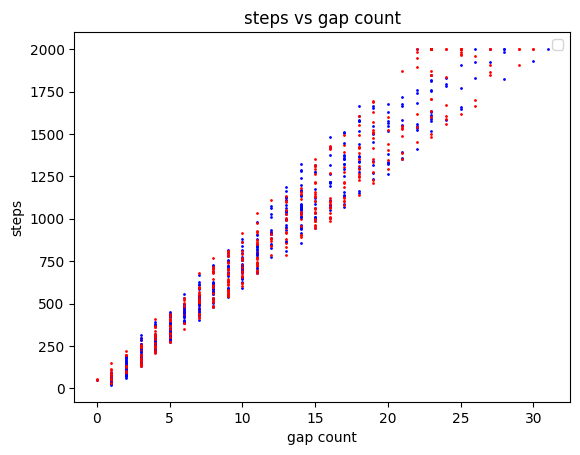

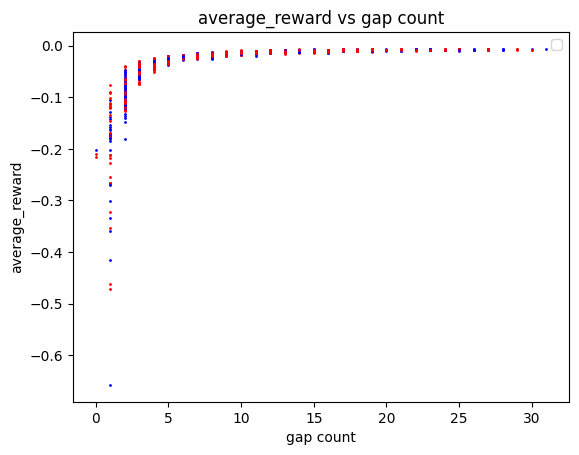

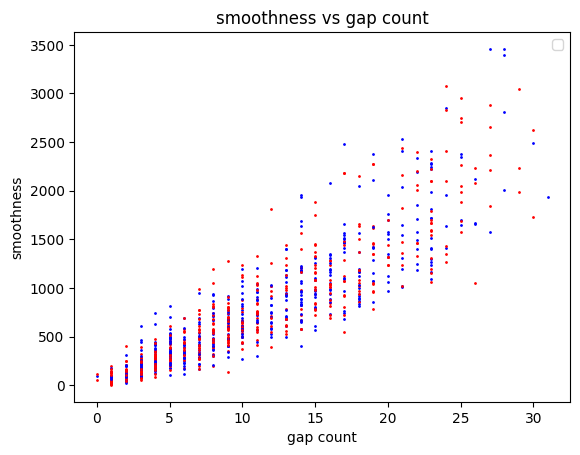

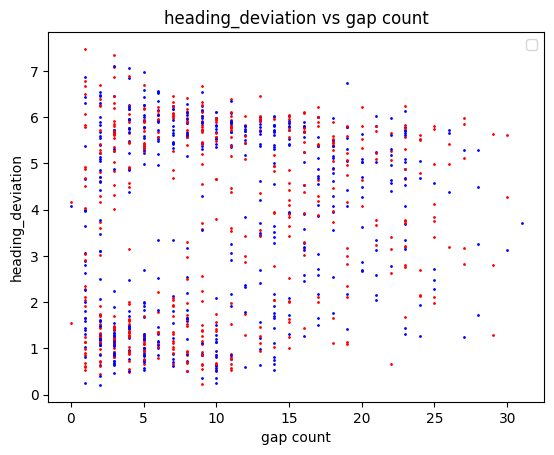

In [28]:
colors = {"Dreamer(recovery)": "red", "Dreamer": "blue"}

for attr in ["steps", "average_reward", "smoothness", "heading_deviation"]:
# for attr in ["steps", "average_reward", "success", "smoothness", "heading_deviation"]:
    plt.figure()
    for name, vals in data.items():
        category = "Dreamer(recovery)" if "recovery" in name.lower() else "Dreamer"
        plt.scatter(vals["others"], vals[attr], color=colors[category], s=1)  # smaller dots
    plt.xlabel("gap count")
    plt.ylabel(attr)
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    plt.title(f"{attr} vs gap count")
    plt.show()

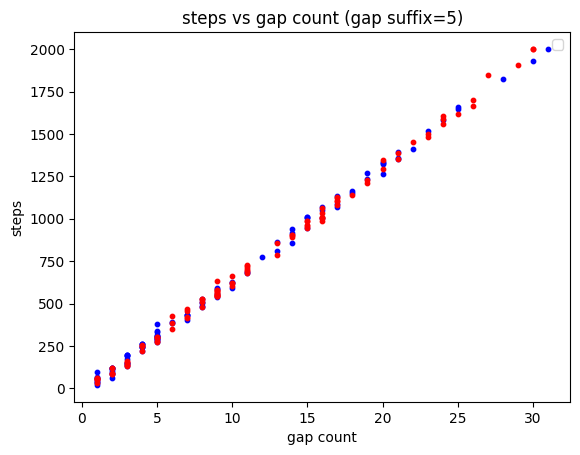

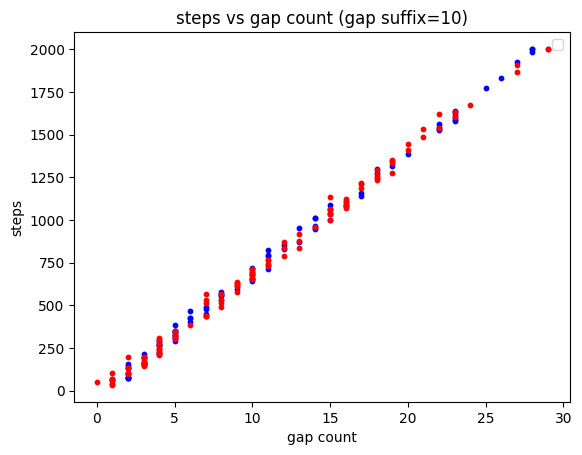

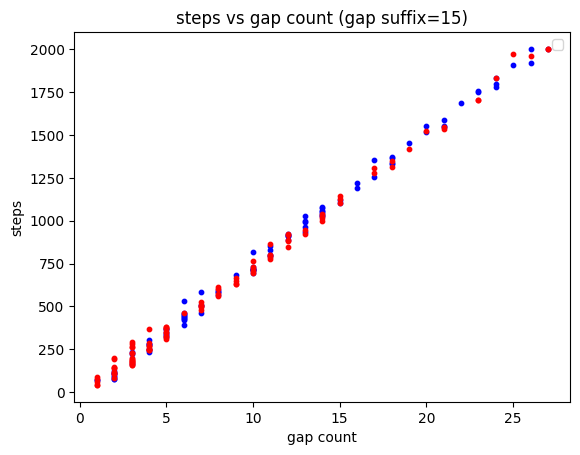

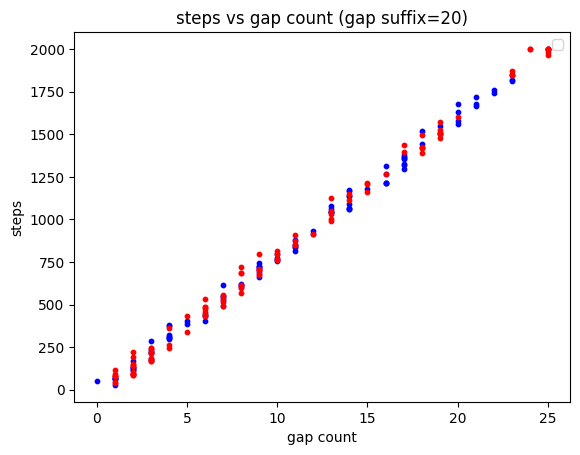

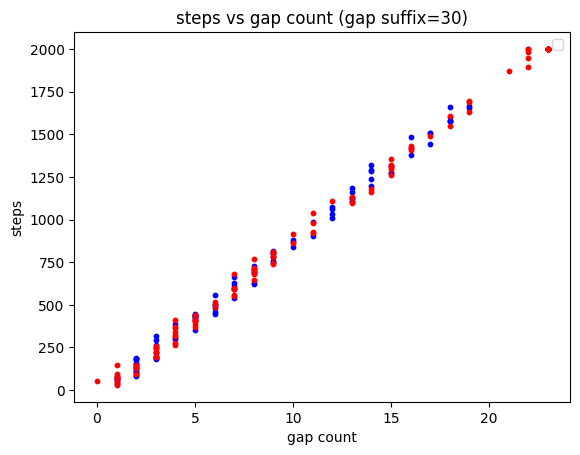

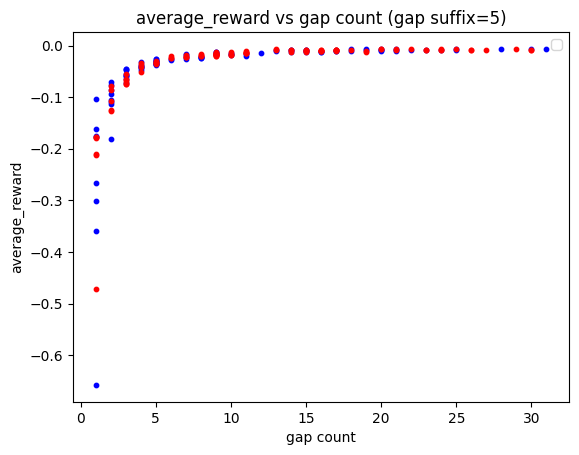

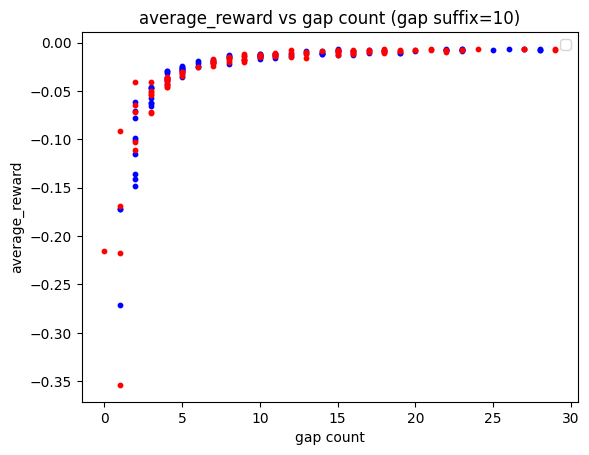

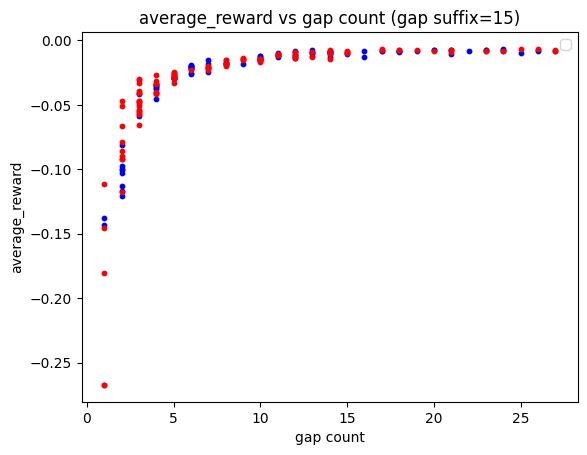

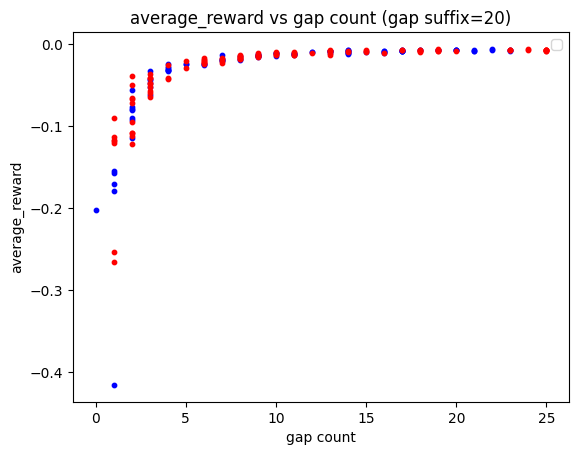

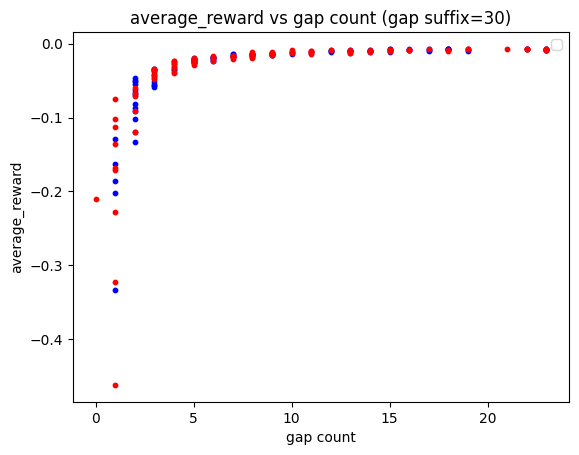

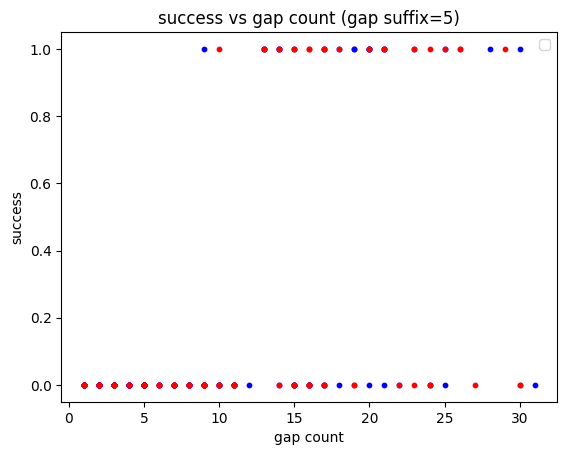

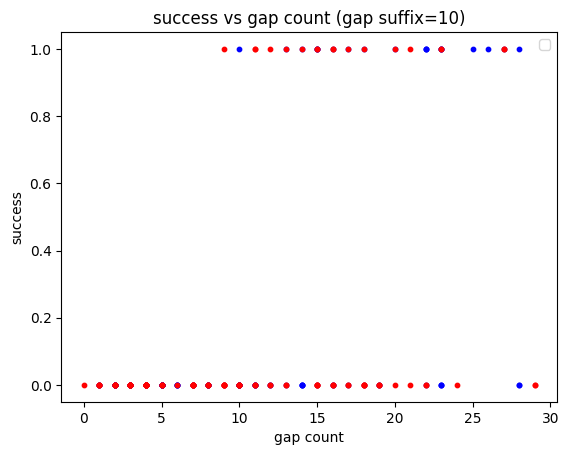

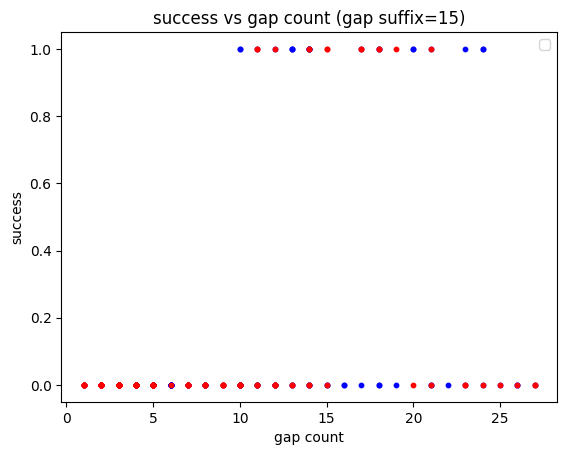

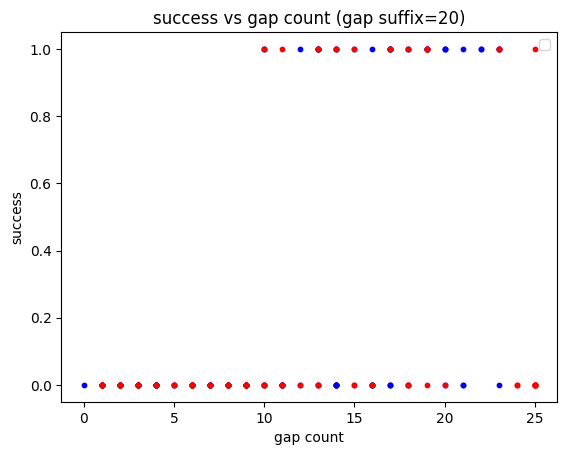

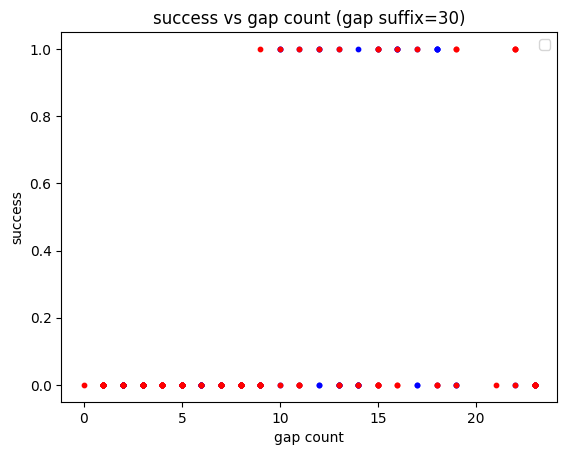

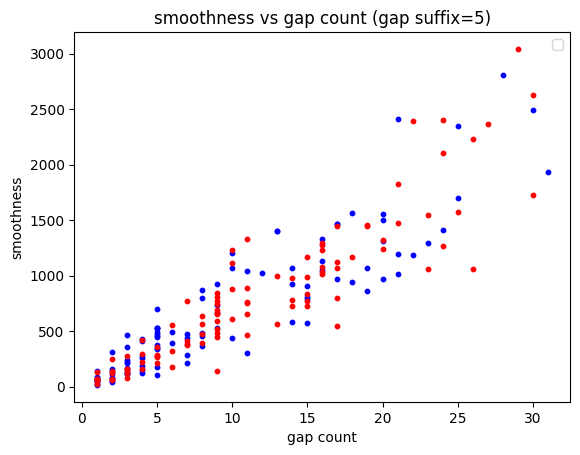

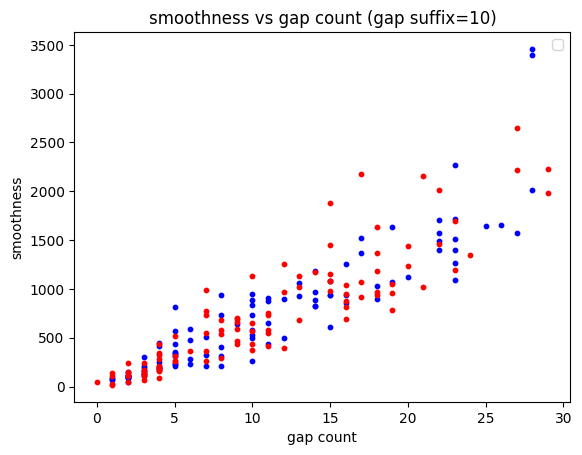

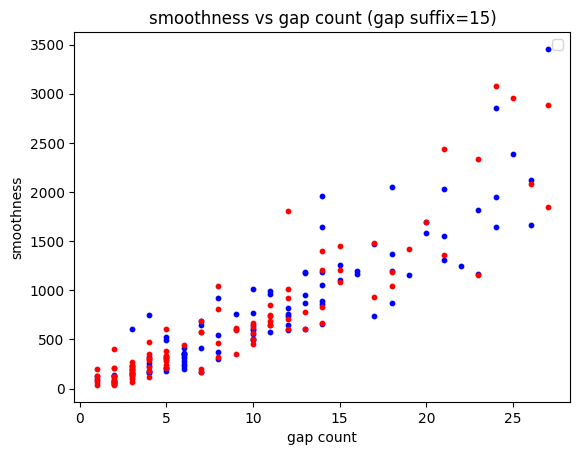

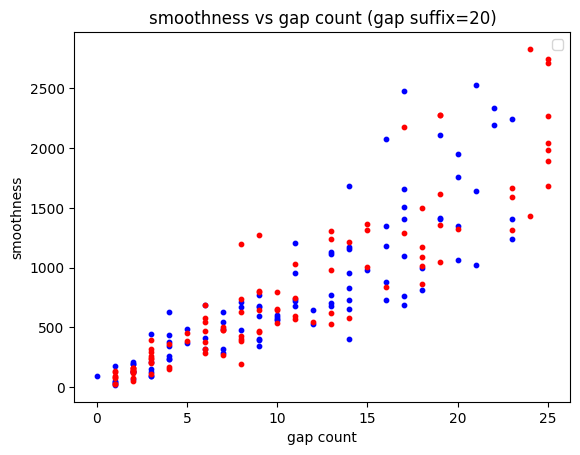

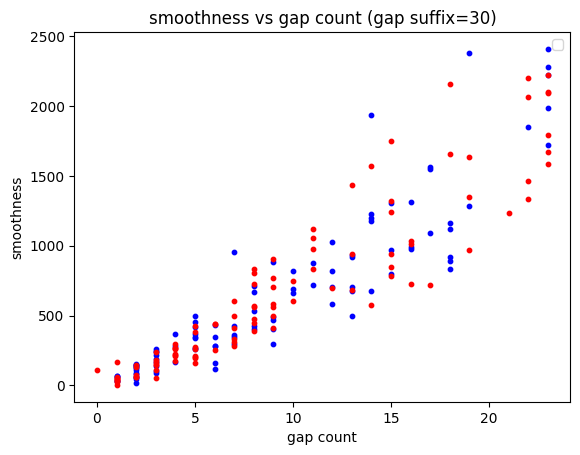

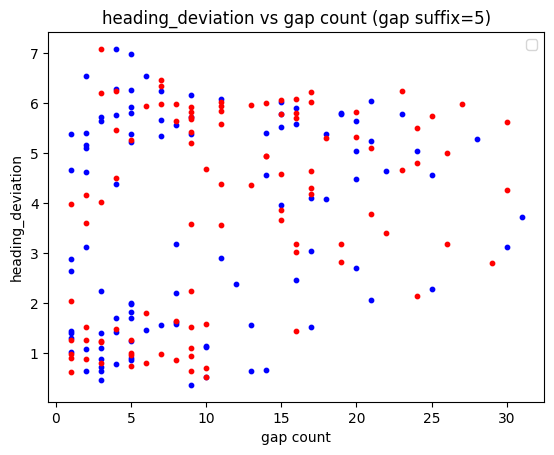

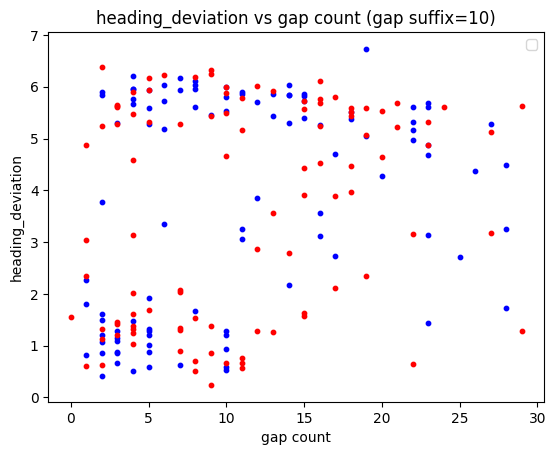

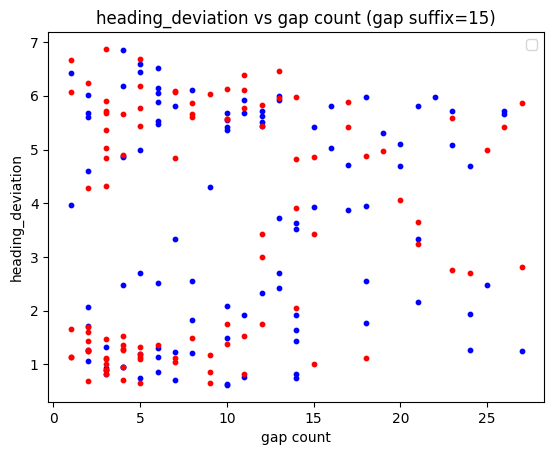

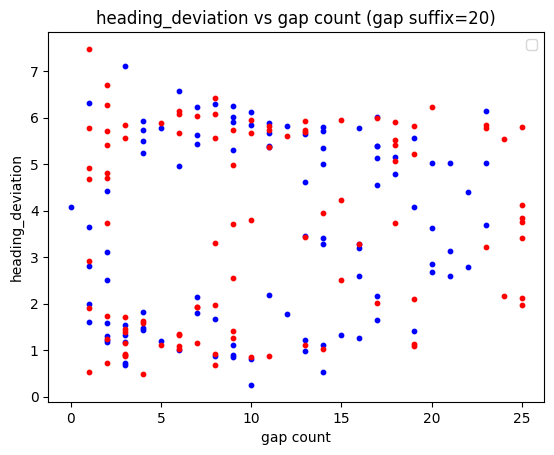

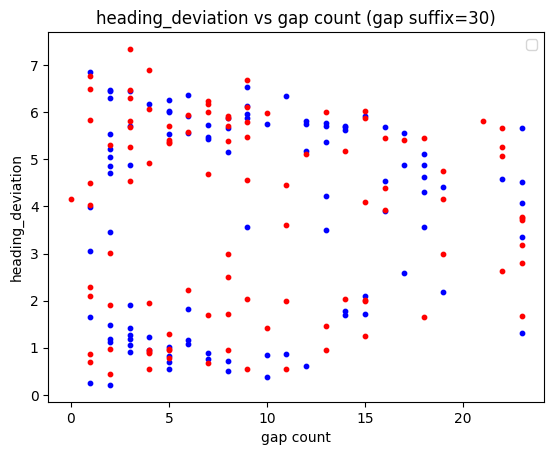

In [18]:
import re

# Extract integer after the dot in _gap.X.Y
def extract_gap_suffix(name):
    match = re.search(r"_gap\.\d+\.(\d+)", name)
    return int(match.group(1)) if match else None

for attr in ["steps", "average_reward", "success", "smoothness", "heading_deviation"]:
    suffix_values = set(filter(None, (extract_gap_suffix(name) for name in data.keys())))
    for suffix in suffix_values:
        plt.figure()
        for name, vals in data.items():
            num = extract_gap_suffix(name)
            if num == suffix:
                category = "Dreamer(recovery)" if "recovery" in name.lower() else "Dreamer"
                plt.scatter(vals["others"], vals[attr], color=colors[category], s=10)
        plt.xlabel("gap count")
        plt.ylabel(attr)
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys())
        plt.title(f"{attr} vs gap count (gap suffix={suffix})")
        plt.show()


In [26]:
colors1 = plt.cm.Blues(np.linspace(0.4, 0.8, 4))
colors2 = plt.cm.Greens(np.linspace(0.4, 0.8, 4))

compare_series1 = {
    'Right': colors1[0],
    'Left': colors1[1],
    'Steering': colors1[2],
    # 'Dreamerdreamer_obs10': colors2[0],
    # 'Dreamerdreamer_obs20': colors2[1],
    # 'Dreamerdreamer_obs30': colors2[2],
    'Dreamer30': 'green'
}

In [27]:
data = raw_data[raw_data['Model'].isin(compare_series1.keys())]
# remove horizon column group by model and obs to forma a pivot table
data = data.drop(columns=['horizon'])
data = data.pivot_table(index='Model', columns='obs', values=['AvgReward', 'Steps', 'Success', 'Smooth', 'Deviation'], aggfunc=np.mean)
for metric in ['AvgReward', 'Steps', 'Success', 'Smooth', 'Deviation']:
    print(data[metric])

obs              10        20        30
Model                                  
Dreamer30 -0.018202 -0.017317 -0.032228
Left      -0.018541 -0.023862 -0.033420
Right     -0.020763 -0.021438 -0.030946
Steering  -0.025138 -0.026268 -0.033346
obs            10      20      30
Model                            
Dreamer30  802.43  604.37  678.86
Left       971.14  643.28  527.60
Right      640.05  614.28  691.59
Steering   870.22  497.75  736.01
obs          10    20    30
Model                      
Dreamer30  0.63  0.68  0.19
Left       0.51  0.60  0.30
Right      0.67  0.58  0.18
Steering   0.50  0.52  0.17
obs                 10          20          30
Model                                         
Dreamer30   890.049525  486.177603  663.234473
Left        969.447007  413.264171  562.950814
Right       447.799611  538.257167  910.628104
Steering   1142.167308  486.134590  608.165106
obs              10        20        30
Model                                  
Dreamer30  4.863730  5.208

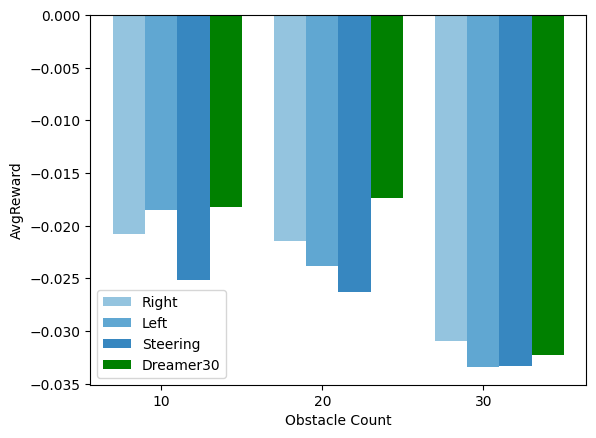

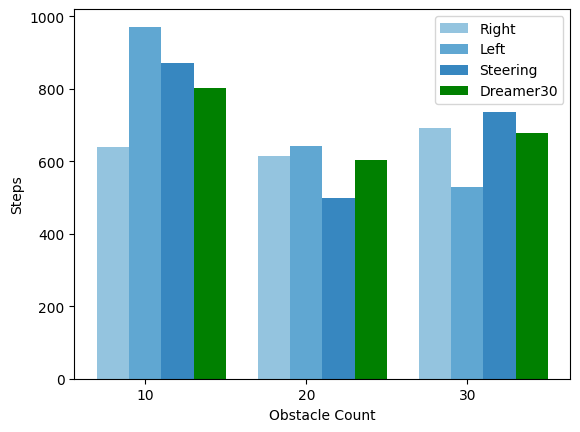

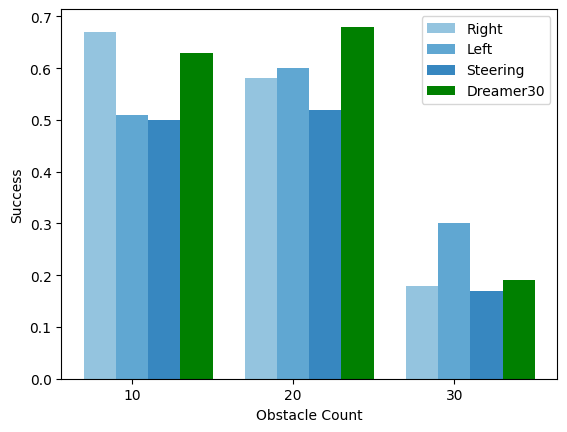

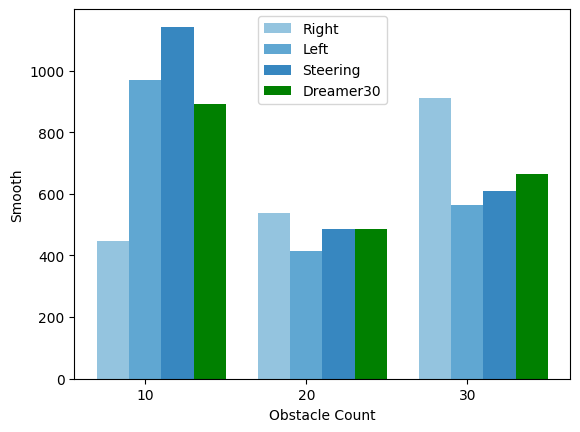

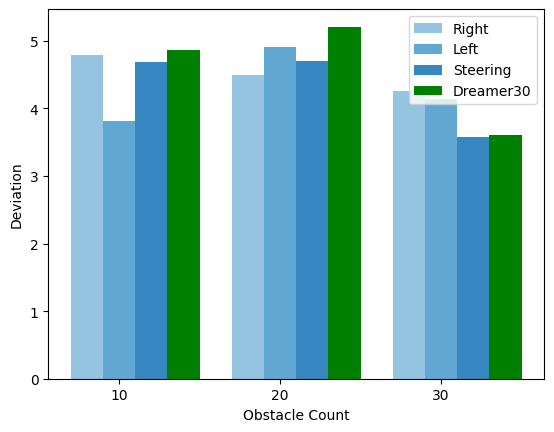

In [28]:
#for each metric, plot a single grouped bar chart base on obstacle count
#only plot for models in compare_series

data = raw_data[raw_data['Model'].isin(compare_series1.keys())]

obs = data['obs'].unique()
x = np.arange(len(obs))
bar_width = 0.2

# for metric in ['AvgReward']:#, 'Steps', 'Success', 'Smooth', 'Deviation']:
for metric in ['AvgReward', 'Steps', 'Success', 'Smooth', 'Deviation']:
    for i, (model, color) in enumerate(compare_series1.items()):
        vals = [data[(data['Model'] == model) & (data['obs'] == o)][metric].values[0] if not data[(data['Model'] == model) & (data['obs'] == o)].empty else 0 for o in obs]
        plt.bar(x + i * bar_width, vals, width=bar_width, label=model, color=color)

    plt.xticks(x + bar_width, obs)
    plt.xlabel('Obstacle Count')
    plt.ylabel(metric)
    plt.legend()
    plt.savefig(f'result_{metric.lower()}_compare_plot.png')
    plt.show()

In [23]:
colors2 = plt.cm.Greens(np.linspace(0.3, 1.0, 5))

compare_series2 = {
    'Dreamer10': colors2[0],
    'Dreamer20': colors2[1],
    'Dreamer30': colors2[2],
    'Dreamer40': colors2[3],
    'Dreamer50': colors2[4]
}

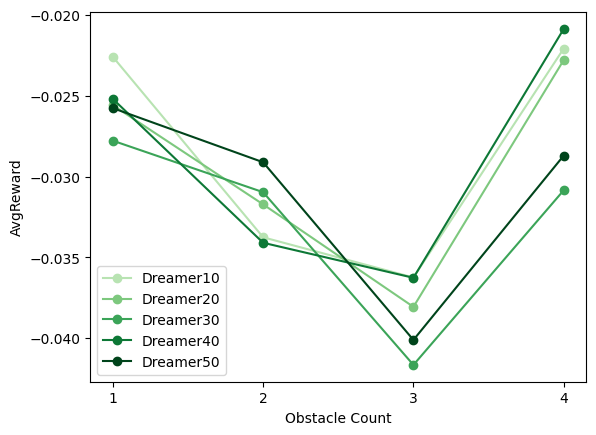

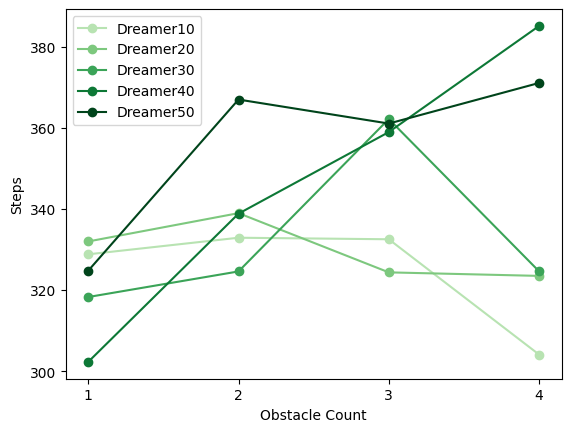

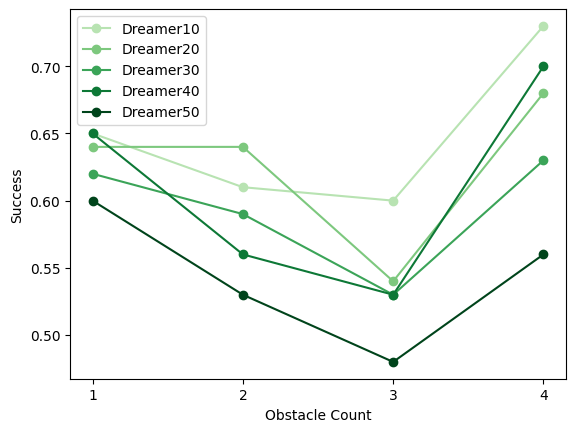

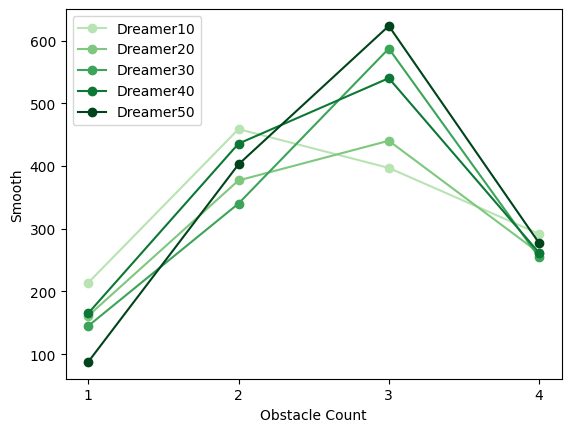

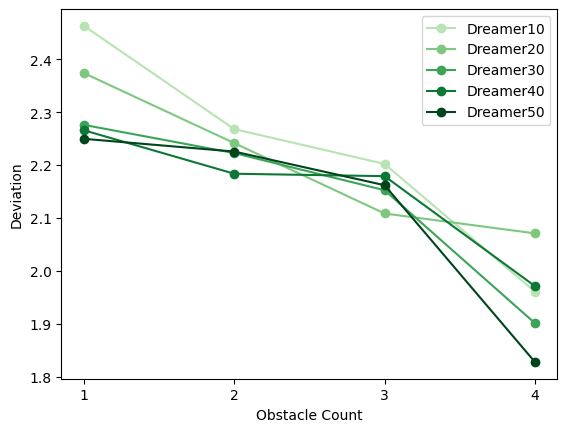

In [100]:
#for each metric, plot a single line chart along the obstacle count
#each model is a separate line
#only plot for models in compare_series

data = raw_data[raw_data['Model'].isin(compare_series2.keys())]

obs = data['obs'].unique()
x = np.arange(len(obs))

for metric in ['AvgReward', 'Steps', 'Success', 'Smooth', 'Deviation']:
    for i, (model, color) in enumerate(compare_series2.items()):
        vals = [data[(data['Model'] == model) & (data['obs'] == o)][metric].values[0] if not data[(data['Model'] == model) & (data['obs'] == o)].empty else 0 for o in obs]
        plt.plot(x, vals, label=model, color=color, marker='o')

    plt.xticks(x, obs)
    plt.xlabel('Obstacle Count')
    plt.ylabel(metric)
    plt.legend()
    plt.savefig(f'result_{metric.lower()}_dreamer_plot.png')
    plt.show()

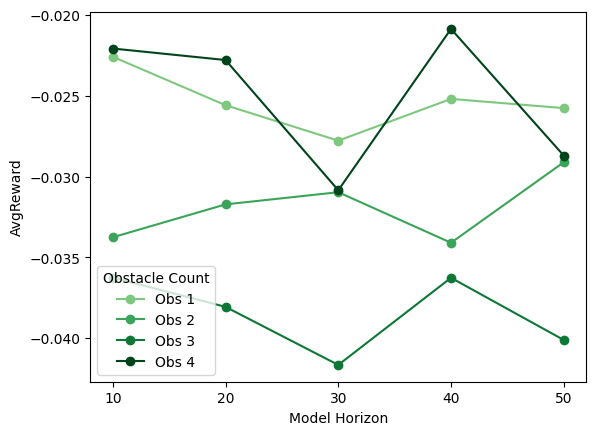

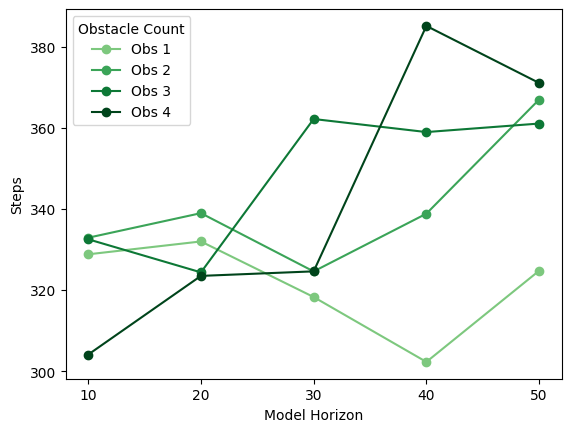

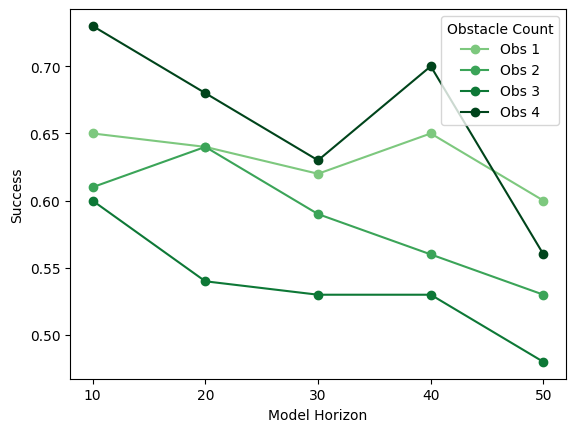

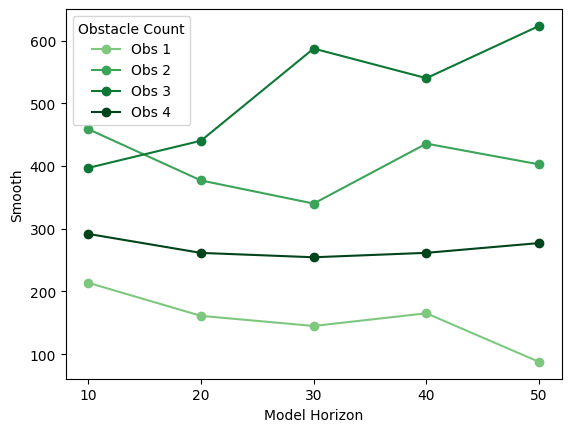

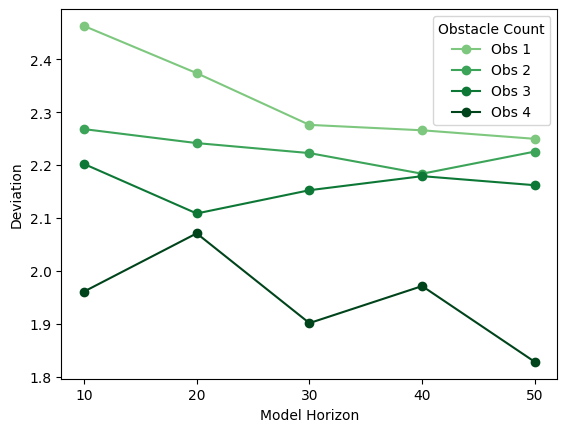

In [24]:
#for each metric, plot a single line chart along the obstacle count
#each model is a separate line
#only plot for models in compare_series

data = raw_data[raw_data['Model'].isin(compare_series2.keys())]

horizons = [10, 20, 30, 40, 50]
x = np.arange(len(horizons))

for metric in ['AvgReward', 'Steps', 'Success', 'Smooth', 'Deviation']:
    for obs_count in data['obs'].unique():
        vals = [data[(data['obs'] == obs_count) & (data['horizon'] == h)][metric].values[0] 
                if not data[(data['obs'] == obs_count) & (data['horizon'] == h)].empty else 0 
                for h in horizons]
        plt.plot(x, vals, label=f'Obs {obs_count}',color=colors2[obs_count], marker='o')

    plt.xticks(x, horizons)
    plt.xlabel('Model Horizon')
    plt.ylabel(metric)
    plt.legend(title='Obstacle Count')
    plt.savefig(f'result_{metric.lower()}_horizon_plot.png')
    plt.show()